In [1]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader

In [2]:
models = torch.load("../models.pt")
image_config = "../simulation_parameters.json"
simulation_batch_size = 160
n_workers=4
device="cuda"
BATCH_SIZE = 32
image_config = json.load(open(image_config))
num_pixels = torch.tensor(
        image_config["N_PIXELS"], dtype=torch.float32, device=device
    )
pixel_size = torch.tensor(
        image_config["PIXEL_SIZE"], dtype=torch.float32, device=device
    )
images = torch.load("../images.pt")
train_config = "../training_parameters_nle.json"
train_config = json.load(open(train_config))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(
        image_prior, batch_size=simulation_batch_size, num_workers=n_workers
    )

In [3]:
estimator = est_utils.load_estimator(
    "../training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "../tutorial_estimator.pt",
    device="cuda",
)

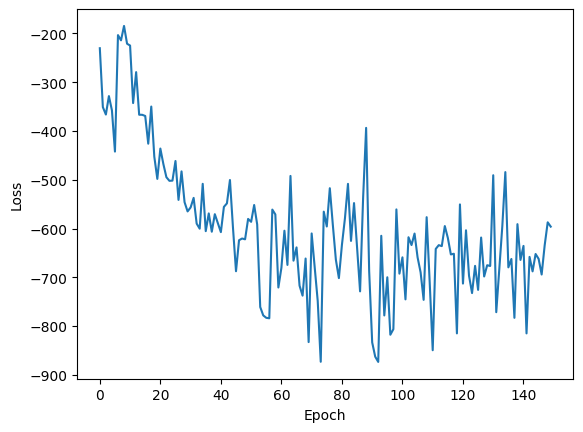

In [4]:
plt.plot(torch.load("../tutorial.loss"))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [25]:
estimator.eval()
num_images = images.shape[0]
num_thetas = models.shape[0]

models_selected = models.transpose(1, 2)

In [23]:
log_probs_all = torch.empty(num_images,num_thetas)

In [63]:
device = 'cuda'
with torch.no_grad():
    a = estimator.forward(images[100].to(device),  models.to(device))

In [29]:
def evaluate_log_prob(estimator, images, models, device="cuda"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, H, W]
        theta: torch.Tensor of shape [num_thetas, ...]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    num_images = images.shape[0]
    num_thetas = models.shape[0]

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        image_flat = images.view(1, -1).to(device)
        posterior = estimator.flow(models.to(device))  
        log_probs_all[:, img_idx] = posterior.log_prob(image_flat).cuda()

    return log_probs_all

In [23]:
def evaluate_log_prob_2(estimator, images, theta, device="cuda"):
    """
    Computes the log-likelihood matrix: all θ × all images.
    Flow is conditioned on theta (NLE setup).

    Args:
        estimator: NLEWithEmbedding trained model
        images: torch.Tensor of shape [num_images, C, H, W]
        theta: torch.Tensor of shape [num_thetas, param_dim]
        device: device to compute on

    Returns:
        log_probs: [num_thetas, num_images] tensor
    """
    estimator.eval()
    images = images.to(device)
    theta = theta.to(device)
    
    num_images = images.shape[0]
    num_thetas = theta.shape[0]

    log_probs_all = torch.empty(num_thetas, num_images)

    with torch.no_grad():
        # Compute θ-conditioned flows for all θ at once
        # The flow distribution returns log_prob for a batch of images
        for img_idx, image in enumerate(images):
            # Keep image in its original shape, add batch dim
            image_batch = image.unsqueeze(0)  # [1, C, H, W]
            
            # Compute log-probs for this image under all θ
            log_probs = estimator(image_batch.repeat(num_thetas, 1, 1, 1), theta)
            # log_probs shape: [num_thetas, 1], squeeze to [num_thetas]
            log_probs_all[:, img_idx] = log_probs.squeeze(-1).cpu()

    return log_probs_all


In [30]:
log = evaluate_log_prob(estimator, images, models, device="cuda")


OutOfMemoryError: CUDA out of memory. Tried to allocate 15.26 GiB. GPU 0 has a total capacity of 44.40 GiB of which 11.37 GiB is free. Including non-PyTorch memory, this process has 33.02 GiB memory in use. Of the allocated memory 17.33 GiB is allocated by PyTorch, and 15.20 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [15]:
print(log.shape)


torch.Size([100, 5000])


In [16]:
np.save('log_prob',log)


In [17]:
log = np.load('log_prob.npy')

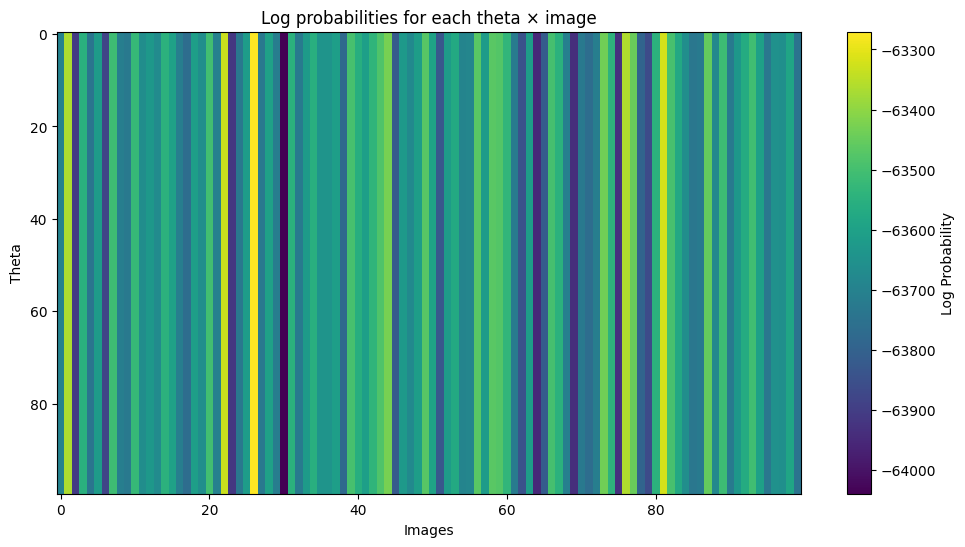

In [16]:
plt.figure(figsize=(12, 6))
plt.imshow(log[:100,:100], aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

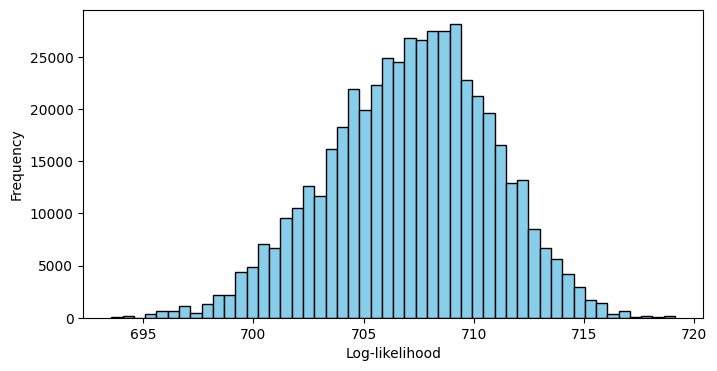

In [57]:
plt.figure(figsize=(8,4))
plt.hist(log.flatten(), bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Log-likelihood")
plt.ylabel("Frequency")
plt.show()

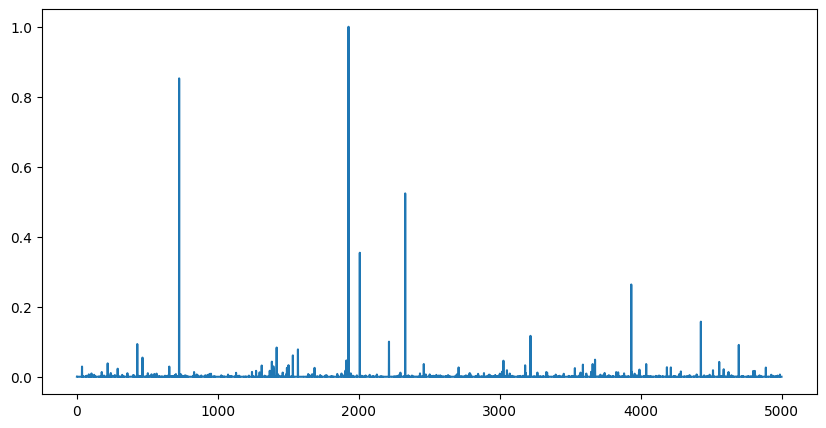

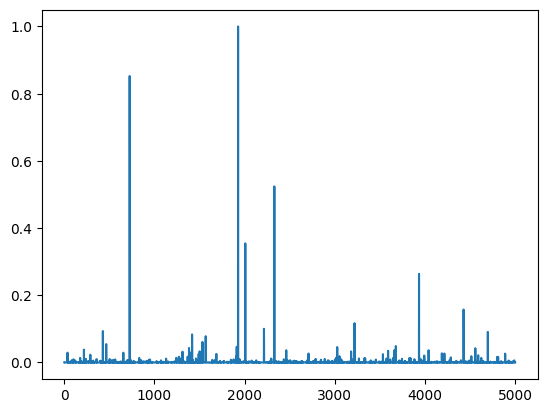

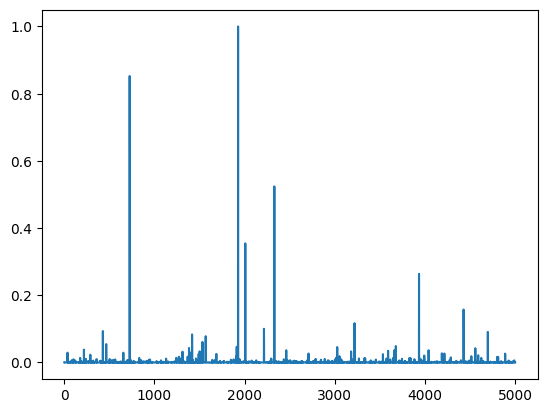

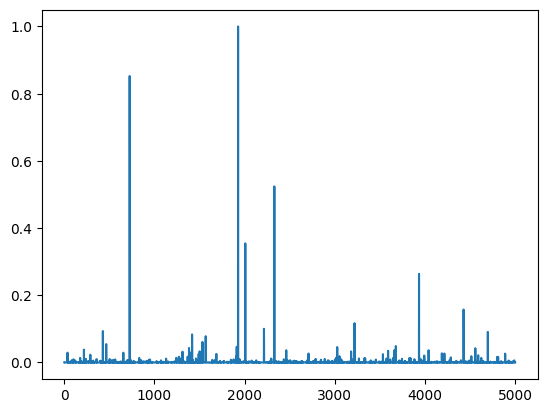

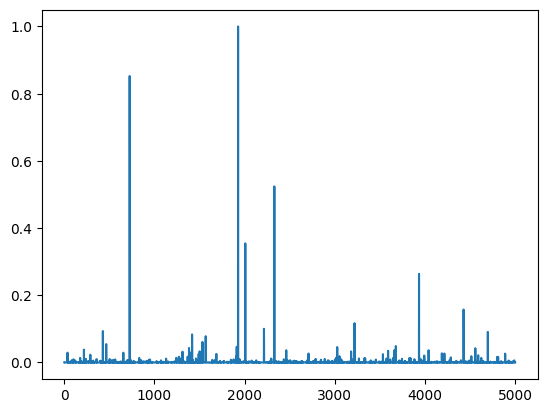

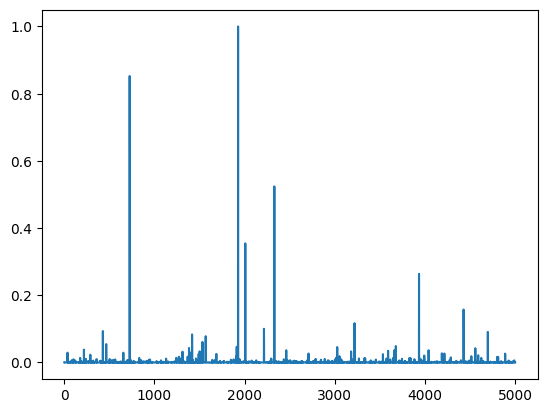

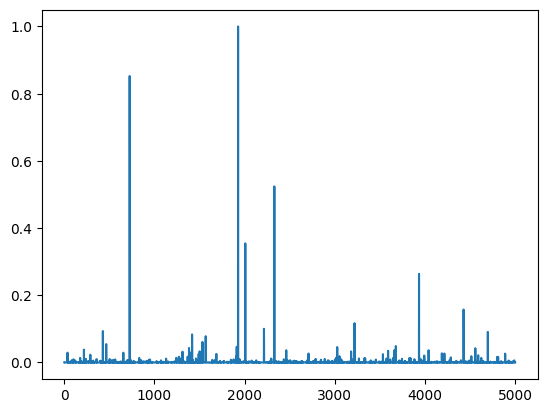

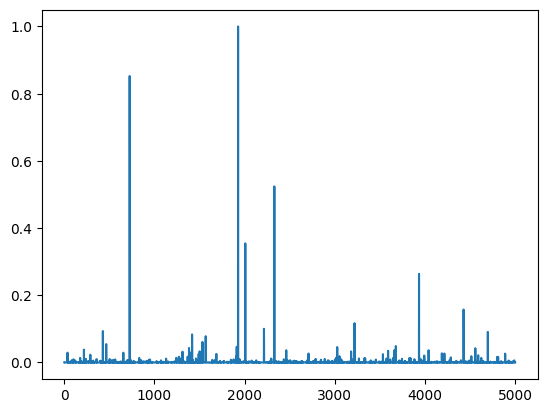

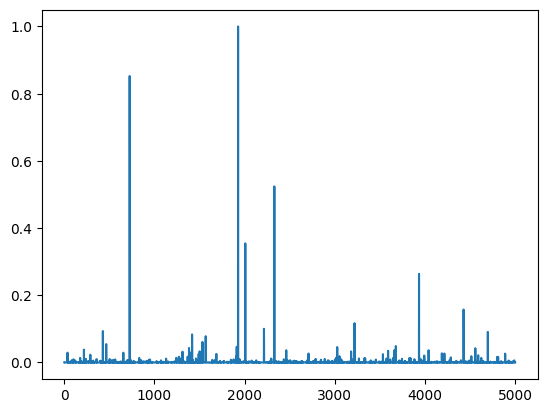

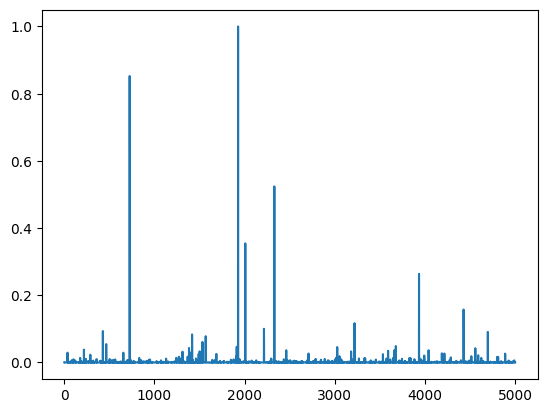

/tmp/ipykernel_262844/3504270936.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


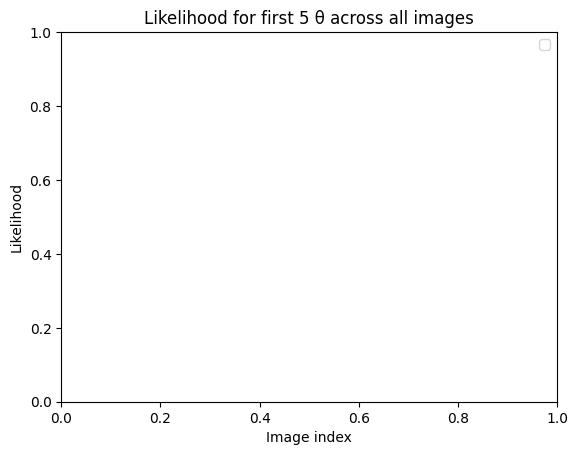

In [19]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.plot(np.exp(log[i] - np.max(log[i])), label=f"theta {i}")
    plt.show()
plt.xlabel("Image index")
plt.ylabel("Likelihood")
plt.title("Likelihood for first 5 θ across all images")
plt.legend()
plt.show()